### Flow map
Now that we have a grid over the $(a,b)$-plane we can visualize the loss landscape. Below the red dot represents the base parameterization from which all other points are reweighed from. The green start is the target parameterization where the loss function (in this case the psuedo-$\chi^2$) should be at a minimum. The arrow represent the gradients of $a$ and $b$ at each grid point.

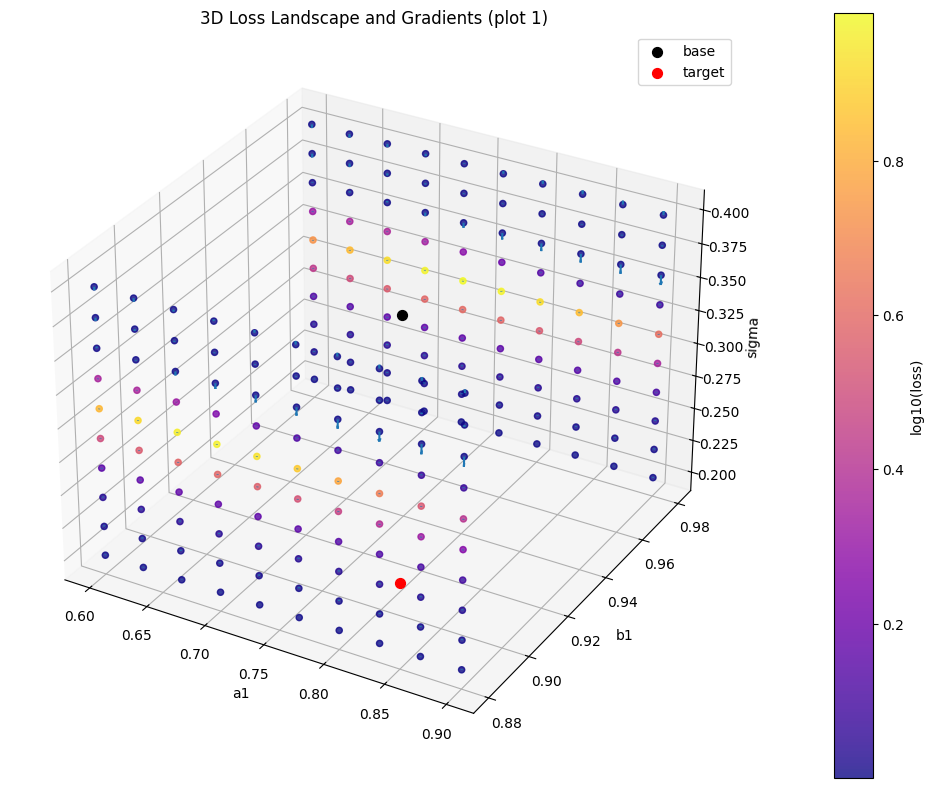

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -- Load data for the chosen plot --
plot_nm = '1'
observable = 'p_all_skew'
gradients     = np.load(f'temp_results/Flow_map/3D/{observable}/gradients_{plot_nm}.npy')
magnitudes    = np.load(f'temp_results/Flow_map/3D/{observable}/magnitudes_{plot_nm}.npy')
loss_grid     = np.load(f'temp_results/Flow_map/3D/{observable}/loss_grid_{plot_nm}.npy')
mu_sigmamu    = np.load(f'temp_results/Flow_map/3D/{observable}/mu_{plot_nm}.npy')
Neff          = np.load(f'temp_results/Flow_map/3D/{observable}/Neff_{plot_nm}.npy')
mu, sigmamu   = mu_sigmamu[:, 0], mu_sigmamu[:, 1]
params_grid   = np.load(f'temp_results/Flow_map/3D/{observable}/params_grid_{plot_nm}.npy')
ordered_params = np.load(f'temp_results/Flow_map/3D/{observable}/ordered_params_{plot_nm}.npy')


# Configuration per plot_nm: scale and base/target points
plot3d_configs = {
    '0': {'scale': 3e3, 'base': (0.68, 0.98, 0.335), 'target': (0.85, 0.88, 0.25)},
    '1': {'scale': 3e3, 'base': (0.68 + 0.0425, 0.955, 0.31375), 'target': (0.68 + 0.17, 0.88, 0.25)},
}
config = plot3d_configs.get(plot_nm)
if config is None:
    raise ValueError(f"Unsupported plot_nm: {plot_nm}")

# Unpack coordinates and gradients
p1, p2, p3 = params_grid[:, 0], params_grid[:, 1], params_grid[:, 2]
g1, g2, g3  = -gradients[:, 0], -gradients[:, 1], -gradients[:, 2]

# Create 3D figure
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

# Plot base and target
ax.scatter(*config['base'],  marker='o', color='black', s=50, label='base')
ax.scatter(*config['target'], marker='o', color='red',   s=50, label='target')

# Quiver for gradient field
ax.quiver(p1, p2, p3,
          g1 / config['scale'],
          g2 / config['scale'],
          g3 / config['scale'],
          length=1.0, normalize=False)

# Scatter colored by loss value
sc = ax.scatter(p1, p2, p3,
                # c=np.log10(loss_grid), cmap='plasma',
                c=Neff, cmap='plasma',
                s=20, alpha=0.8)
cbar = fig.colorbar(sc, pad=0.1)
cbar.set_label('log10(loss)')

# Labels and legend
ax.set_xlabel(f'{ordered_params[0]}')
ax.set_ylabel(f'{ordered_params[1]}')
ax.set_zlabel(f'{ordered_params[2]}')
ax.set_title(f'3D Loss Landscape and Gradients (plot {plot_nm})')
ax.legend()
plt.tight_layout()
plt.show()


In [2]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Configuration per plot_nm: scale, head_width, head_length, base (a,b,sigma), target (a,b,sigma)
# plot_configs = {
#     '0':{'scale':5e3,'head_width':0.004,'head_length':0.003,'base':{'a':0.68 + 0.0425,'b':0.955,'sigma':0.31375},'target':{'a':0.85,'b':0.88,'sigma':0.25}},
#     '72':{'scale':5e3,'head_width':0.004,'head_length':0.003,'base':{'a':0.68 + 0.0425,'b':0.955,'sigma':0.31375},'target':{'a':0.85,'b':0.88,'sigma':0.25}},
#     '1': {'scale': 3e3, 'base': (0.68 + 0.0425, 0.955, 0.31375), 'target': (0.68 + 0.17, 0.88, 0.25)},

# }
# config = plot_configs.get(plot_nm)
# if config is None:
#     raise ValueError(f"Unsupported plot_nm: {plot_nm}")

# # Metrics to display
# metrics = {
#     'loss': {'values': lambda: np.log10(loss_grid), 'label': 'log10(loss)'},
#     'mu':   {'values': lambda: mu,               'label': r"$\ln\left|\frac{1-\mu}{\sigma_{1-\mu}}\right|$"},
#     'Neff': {'values': lambda: Neff,             'label': 'Neff'},
# }

# # Unique bd values to slice
# bds = np.unique(a_b_c[:,1])

# for metric_key, metric in metrics.items():
#     vals = metric['values']()
#     for bd_val in bds:
#         mask = (a_b_c[:,1] == bd_val)
#         ad_vals = a_b_c[mask,0]
#         au_vals = a_b_c[mask,2]
#         grads   = a_b_gradients[mask]
#         m_vals  = vals[mask]

#         # Build grid
#         ad_u = np.unique(ad_vals)
#         au_u = np.unique(au_vals)
#         A, U = np.meshgrid(ad_u, au_u, indexing='ij')
#         Z    = m_vals.reshape(len(ad_u), len(au_u))

#         # Plot
#         plt.figure(figsize=(6,5))
#         pcm = plt.pcolormesh(A, U, Z, shading='auto', cmap='plasma')
#         plt.colorbar(pcm, label=metric['label'])

#         # Gradient arrows
#         for (x,y), g in zip(np.vstack([ad_vals, au_vals]).T, grads):
#             dx = -g[0] / config['scale']
#             dy = -g[2] / config['scale']
#             plt.arrow(x, y, dx, dy,
#                       head_width=config['head_width'],
#                       head_length=config['head_length'],
#                       fc='k', ec='k', linewidth=0.7)

#         # Base and target markers
#         base = config['base']
#         tgt  = config['target']
#         plt.plot(base['a'], base['sigma'], 'o', color='black', markersize=6, label='base')
#         plt.plot(tgt['a'],  tgt['sigma'],'o', color='red',   markersize=6, label='target')

#         # Title uses base/target b and sigma
#         title = (
#             f"Metric={metric_key} | b_d={bd_val:.3f}\n"
#             f"base: a={base['a']}, b={base['b']}, sigma={base['sigma']}\n"
#             f"target: a={tgt['a']}, b={tgt['b']}, sigma={tgt['sigma']}"
#         )
#         plt.title(title)
#         plt.xlabel('a_d')
#         plt.ylabel('sigma')
#         plt.legend(loc='lower left')
#         plt.tight_layout()
#         # if bd_val.round(3) == 0.878 or bd_val.round(3) == 0.967:
#             # plt.savefig(f'temp_results/Flow_map_nD/plots/{plot_nm}_{metric_key}_bd_{bd_val:.3f}.png', dpi=300)
#         plt.savefig(f'temp_results/Flow_map_nD/plots/{plot_nm}_{metric_key}_bd_{bd_val:.3f}.png', dpi=300)


[[3.85343772e-03 1.00829415e-02 3.12473997e-02 1.22588277e-01
  4.30489838e-01 7.28107333e-01 3.20765615e-01 5.00260247e-03
  2.76437117e-04 6.93617403e-05]
 [3.68594774e-03 1.04919970e-02 3.46449316e-02 1.43225625e-01
  5.01949310e-01 8.39972138e-01 3.58108461e-01 4.54346323e-03
  3.11492215e-04 7.70882179e-05]
 [3.39434925e-03 1.05772773e-02 3.61693613e-02 1.56264886e-01
  5.57101548e-01 9.23741400e-01 3.72504473e-01 3.07393447e-03
  3.13034019e-04 8.79943909e-05]
 [3.00326105e-03 1.02797775e-02 3.59193534e-02 1.62048206e-01
  5.90807974e-01 9.74911332e-01 3.44488859e-01 1.60989817e-03
  2.48749711e-04 1.01889113e-04]
 [2.56447564e-03 9.68355406e-03 3.46112773e-02 1.62291661e-01
  6.00511014e-01 9.91434991e-01 2.73520976e-01 8.14492349e-04
  1.67380218e-04 1.14974828e-04]
 [2.13712081e-03 8.93638935e-03 3.29716951e-02 1.58249259e-01
  5.85808396e-01 9.73195374e-01 1.93612635e-01 4.57829592e-04
  1.13030772e-04 1.19947414e-04]
 [1.76432251e-03 8.15791357e-03 3.13504115e-02 1.50397122e

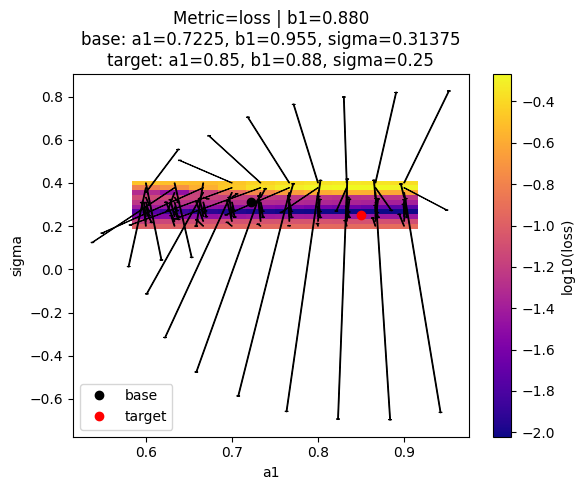

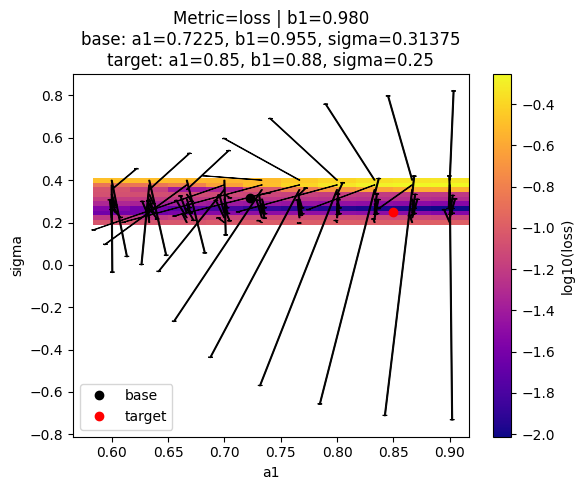

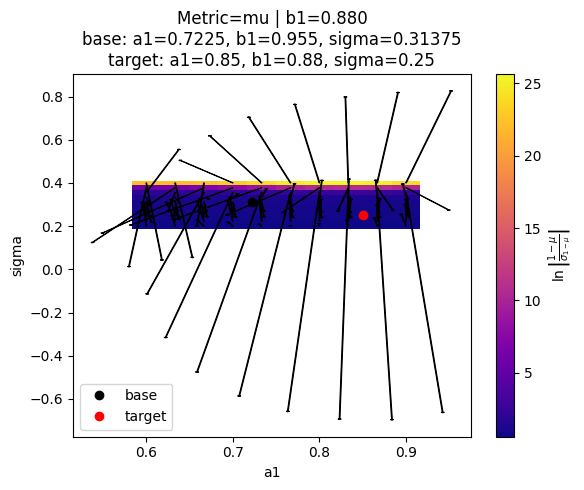

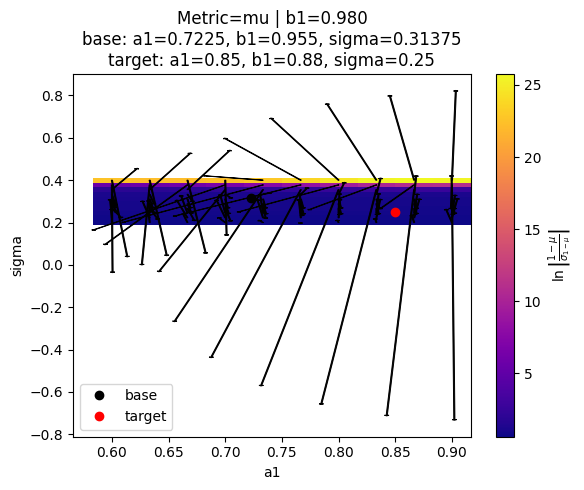

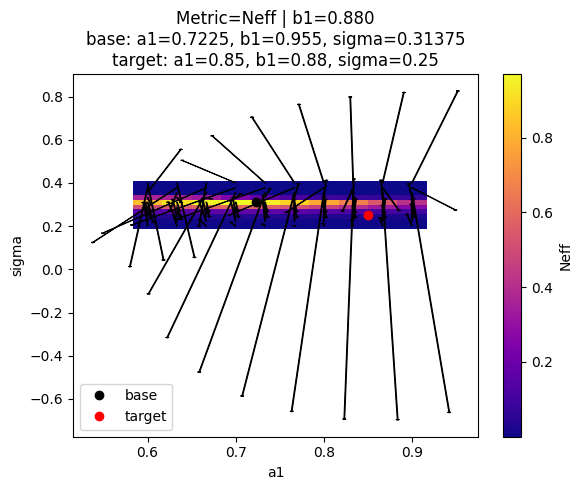

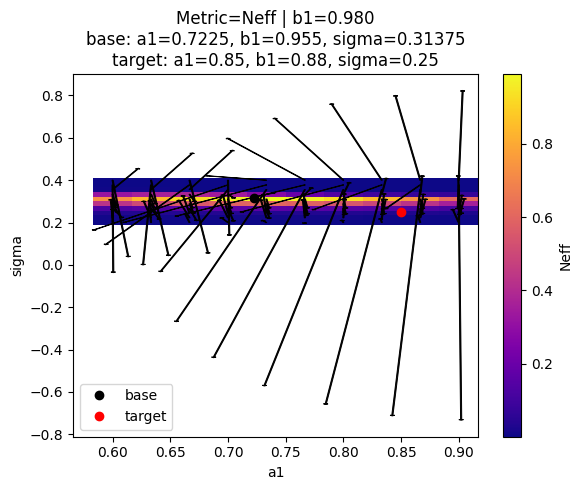

In [ ]:
# import os
# import numpy as np
# import matplotlib.pyplot as plt

# # -- Load data for the chosen plot --
# plot_nm = '1'
# gradients     = np.load(f'temp_results/Flow_map/3D/{observable}/gradients_{plot_nm}.npy')
# loss_grid     = np.load(f'temp_results/Flow_map/3D/{observable}/loss_grid_{plot_nm}.npy')
# mu_sigmamu    = np.load(f'temp_results/Flow_map/3D/{observable}/mu_{plot_nm}.npy')
# Neff          = np.load(f'temp_results/Flow_map/3D/{observable}/Neff_{plot_nm}.npy')
# params_grid   = np.load(f'temp_results/Flow_map/3D/{observable}/params_grid_{plot_nm}.npy')
# ordered_params = np.load(f'temp_results/Flow_map/3D/{observable}/ordered_params_{plot_nm}.npy')

# # Unpack weight metrics
# mu, sigmamu = mu_sigmamu[:, 0], mu_sigmamu[:, 1]

# # Configuration per plot_nm: scale, arrow head sizes, base & target points
# plot3d_configs = {
#     '0': {'scale':      5e3, 'head_width': 0.004, 'head_length':0.003, 'base':   (0.68 + 0.0425, 0.955, 0.31375), 'target': (0.85,         0.88,  0.25)},
#     '1': {'scale':      2e1, 'head_width': 0.004, 'head_length':0.003, 'base':   (0.68 + 0.0425, 0.955, 0.31375), 'target': (0.85,         0.88,  0.25)},
# }
# config = plot3d_configs.get(plot_nm)
# if config is None:
#     raise ValueError(f"Unsupported plot_nm: {plot_nm}")

# # Metrics to display
# metrics = {
#     'loss': {'values': lambda: np.log10(loss_grid), 'label': 'log10(loss)'},
#     'mu':   {'values': lambda: mu,                  'label': r"$\ln\left|\frac{1-\mu}{\sigma_{1-\mu}}\right|$"},
#     'Neff': {'values': lambda: Neff,                'label': 'Neff'},
# }

# # Prepare output folder
# out_folder = 'temp_results/Flow_map_nD/plots'
# os.makedirs(out_folder, exist_ok=True)

# # Slice along the middle parameter (bd = params_grid[:,1])
# bds = np.unique(params_grid[:,1])

# for metric_key, metric in metrics.items():
#     vals = metric['values']()
#     for bd_val in bds:
#         mask    = (params_grid[:,1] == bd_val)
#         p1_vals = params_grid[mask, 0]   # a_d
#         p3_vals = params_grid[mask, 2]   # sigma
#         grads   = gradients[mask]
#         m_vals  = vals[mask]

#         # Build rectangular grid in (a_d, sigma)
#         a_u     = np.unique(p1_vals)
#         s_u     = np.unique(p3_vals)
#         A, S    = np.meshgrid(a_u, s_u, indexing='ij')
#         Z       = m_vals.reshape(len(a_u), len(s_u))

#         # Plot heatmap
#         plt.figure(figsize=(6,5))
#         pcm = plt.pcolormesh(A, S, Z, shading='auto', cmap='plasma')
#         plt.colorbar(pcm, label=metric['label'])

#         # Overlay gradient arrows (negative = descent direction)
#         for (x, z), g in zip(np.vstack([p1_vals, p3_vals]).T, grads):
#             dx = -g[0] / config['scale']
#             dz = -g[2] / config['scale']
#             plt.arrow(x, z, dx, dz,
#                       head_width=config['head_width'],
#                       head_length=config['head_length'],
#                       fc='k', ec='k', linewidth=0.7)

#         # Mark base & target
#         bx, by, bz = config['base']
#         tx, ty, tz = config['target']
#         plt.plot(bx, bz, 'o', color='black', markersize=6, label='base')
#         plt.plot(tx, tz, 'o', color='red',   markersize=6, label='target')

#         # Titles and labels
#         title = (
#             f"Metric={metric_key} | {ordered_params[1]}={bd_val:.3f}\n"
#             f"base: {ordered_params[0]}={bx}, {ordered_params[1]}={by}, {ordered_params[2]}={bz}\n"
#             f"target: {ordered_params[0]}={tx}, {ordered_params[1]}={ty}, {ordered_params[2]}={tz}"
#         )
#         plt.title(title)
#         plt.xlabel(ordered_params[0])
#         plt.ylabel(ordered_params[2])
#         plt.legend(loc='lower left')
#         plt.tight_layout()

#         # Save
#         # fname = f'{plot_nm}_{metric_key}_bd_{bd_val:.3f}.png'
#         # plt.savefig(os.path.join(out_folder, fname), dpi=300)
#         # plt.close()
# print(Z)
# print(dx,dz)

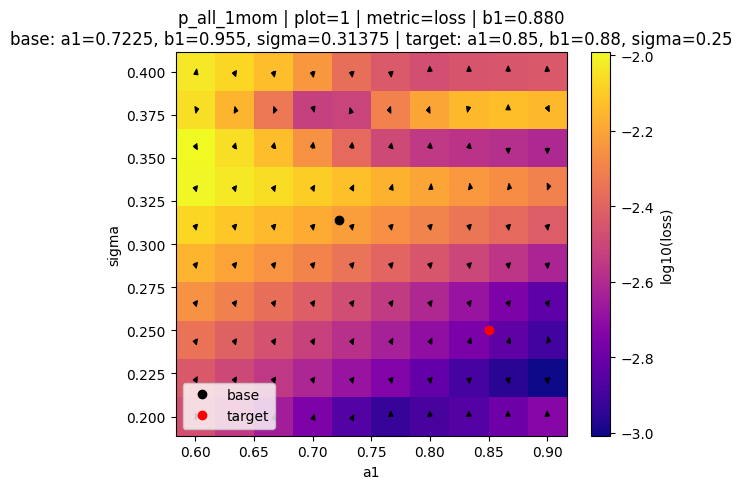

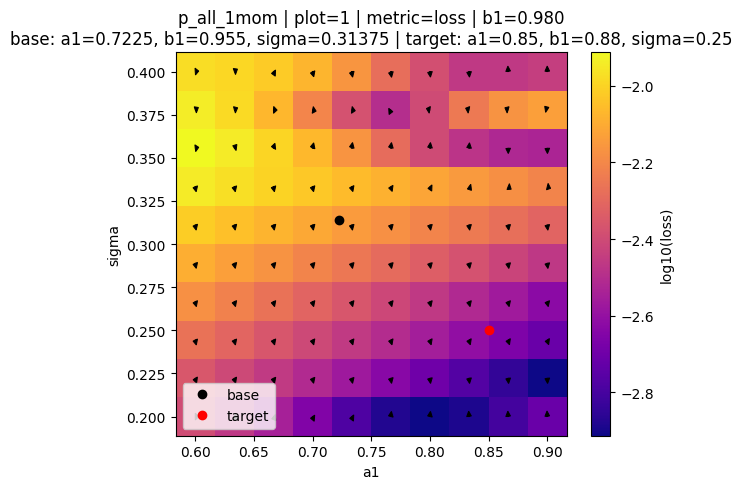

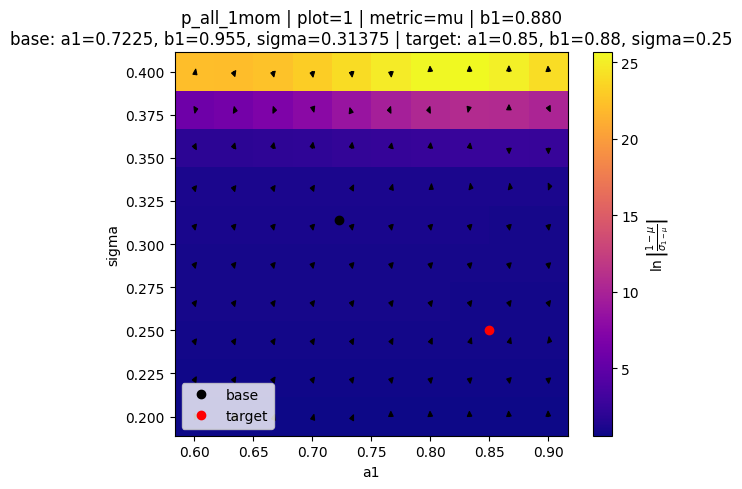

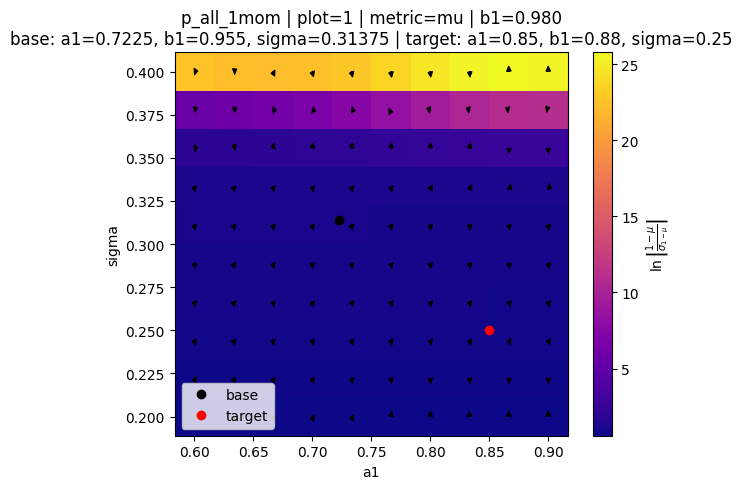

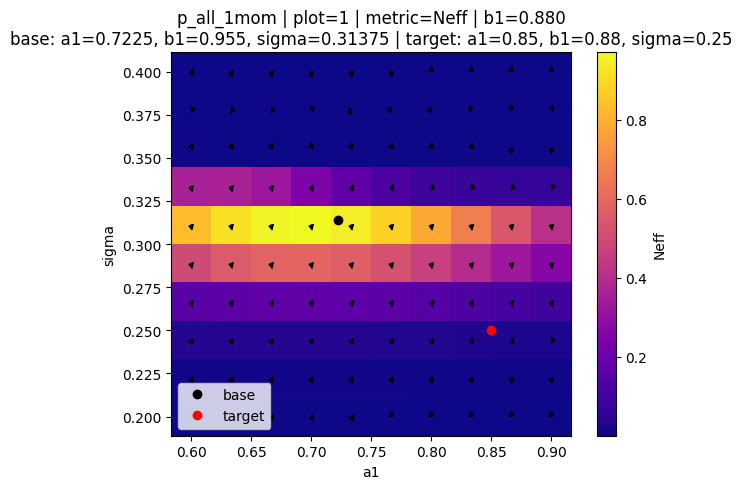

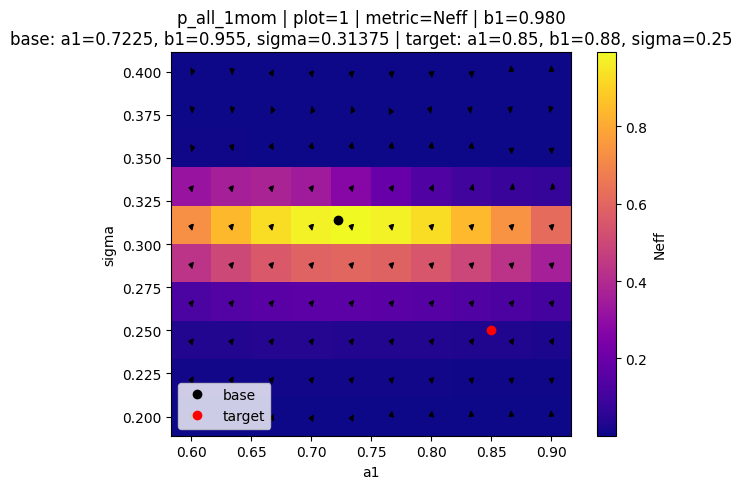

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Choose observable & plot
# =========================
observable = 'p_all_1mom'   # <-- set this
plot_nm    = '1'            # <-- and this ('0', '1', ...)

# =========================
# Configurations per observable (outer) and per plot (inner)
# =========================
plot_configs = {
    'p_all_skew': {
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
    },
    'p_all_1mom': {
        '1': {
            'scale': 6e2,
            'head_width': 0.004,
            'head_length': 0.003,
            'base':   (0.68 + 0.0425, 0.955, 0.31375),
            'target': (0.85,          0.88,  0.25),
        },
    },

    # Add more observables below as needed:
    # 'some_other_observable': {
    #     '0': {...},
    #     '1': {...},
    # },
}

def get_config(obs: str, pnm: str):
    try:
        return plot_configs[obs][pnm]
    except KeyError:
        raise ValueError(f"No config found for observable='{obs}', plot_nm='{pnm}'. "
                         f"Available: {list(plot_configs.keys())}")

config = get_config(observable, plot_nm)

# =========================
# Paths (centralized)
# =========================
base_dir = f"temp_results/Flow_map/3D/{observable}"
out_folder = f"temp_results/Flow_map_nD/plots/{observable}"
os.makedirs(out_folder, exist_ok=True)

# =========================
# Load data
# =========================
gradients      = np.load(os.path.join(base_dir, f'gradients_{plot_nm}.npy'))
loss_grid      = np.load(os.path.join(base_dir, f'loss_grid_{plot_nm}.npy'))
mu_sigmamu     = np.load(os.path.join(base_dir, f'mu_{plot_nm}.npy'))
Neff           = np.load(os.path.join(base_dir, f'Neff_{plot_nm}.npy'))
params_grid    = np.load(os.path.join(base_dir, f'params_grid_{plot_nm}.npy'))
ordered_params = np.load(os.path.join(base_dir, f'ordered_params_{plot_nm}.npy'))

# Ensure ordered_params are strings (handle bytes from npy if present)
def _to_str_list(arr):
    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode('utf-8', errors='ignore'))
        else:
            out.append(str(x))
    return out

ordered_params = _to_str_list(ordered_params)

# Unpack weight metrics
mu, sigmamu = mu_sigmamu[:, 0], mu_sigmamu[:, 1]

# =========================
# Metrics to display
# =========================
metrics = {
    'loss': {
        'values': lambda: np.log10(loss_grid),
        'label':  'log10(loss)'
    },
    'mu':   {
        'values': lambda: mu,
        'label':  r"$\ln\left|\frac{1-\mu}{\sigma_{1-\mu}}\right|$"
    },
    'Neff': {
        'values': lambda: Neff,
        'label':  'Neff'
    },
}

# =========================
# Slice along the middle parameter (bd = params_grid[:,1])
# =========================
bds = np.unique(params_grid[:, 1])

last_Z = None
last_dx = None
last_dz = None

for metric_key, metric in metrics.items():
    vals = metric['values']()
    for bd_val in bds:
        mask    = (params_grid[:, 1] == bd_val)
        p0_vals = params_grid[mask, 0]   # a_d (first param)
        p2_vals = params_grid[mask, 2]   # sigma (third param)
        grads   = gradients[mask]
        m_vals  = vals[mask]

        # Build rectangular grid in (a_d, sigma)
        a_u  = np.unique(p0_vals)
        s_u  = np.unique(p2_vals)
        A, S = np.meshgrid(a_u, s_u, indexing='ij')

        # Safety check: ensure reshaping is consistent
        expected_size = len(a_u) * len(s_u)
        if m_vals.size != expected_size:
            raise ValueError(
                f"Inconsistent grid for bd={bd_val}: metric values size={m_vals.size}, "
                f"expected {expected_size} (len(a_u)={len(a_u)} * len(s_u)={len(s_u)})."
            )

        Z = m_vals.reshape(len(a_u), len(s_u))

        # Plot heatmap
        plt.figure(figsize=(6, 5))
        pcm = plt.pcolormesh(A, S, Z, shading='auto', cmap='plasma')
        plt.colorbar(pcm, label=metric['label'])

        # Overlay gradient arrows (negative = descent direction)
        for (x, z), g in zip(np.vstack([p0_vals, p2_vals]).T, grads):
            dx = -g[0] / config['scale']
            dz = -g[2] / config['scale']
            plt.arrow(
                x, z, dx, dz,
                head_width=config['head_width'],
                head_length=config['head_length'],
                fc='k', ec='k', linewidth=0.7
            )
            last_dx, last_dz = dx, dz  # keep last for printing

        # Mark base & target
        bx, by, bz = config['base']
        tx, ty, tz = config['target']
        plt.plot(bx, bz, 'o', color='black', markersize=6, label='base')
        plt.plot(tx, tz, 'o', color='red',   markersize=6, label='target')

        # Titles and labels
        title = (
            f"{observable} | plot={plot_nm} | metric={metric_key} | {ordered_params[1]}={bd_val:.3f}\n"
            f"base: {ordered_params[0]}={bx}, {ordered_params[1]}={by}, {ordered_params[2]}={bz} | "
            f"target: {ordered_params[0]}={tx}, {ordered_params[1]}={ty}, {ordered_params[2]}={tz}"
        )
        plt.title(title)
        plt.xlabel(ordered_params[0])
        plt.ylabel(ordered_params[2])
        plt.legend(loc='lower left')
        plt.tight_layout()

        # Save
        fname = f'{observable}_plot{plot_nm}_{metric_key}_bd_{bd_val:.3f}.png'
        # plt.savefig(os.path.join(out_folder, fname), dpi=300)
        # plt.close()

        # Keep last Z for printing
        last_Z = Z

# Optional debug prints (last computed grid and last arrow components)
# if last_Z is not None:
#     print(last_Z)
# if (last_dx is not None) and (last_dz is not None):
#     print(last_dx, last_dz)
